# Load Dataset

In [1]:
import json
import pandas as pd

path = "/kaggle/input/dataaaa/code_features.jsonl"

records = []
with open(path, "r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)

df.head()


,code,complexity,representation,num_loops,num_for,num_while,max_loop_depth,has_nested_loops,loop_bound_type,has_log_update,...,has_continue,has_early_return,num_return,uses_comprehension,uses_generator,num_function_calls,uses_list,uses_dict,uses_set,uses_tuple
0,"from math import sqrt\na, v = map(int, input()...",constant,ast_static_complete,0,0,0,0,0,unknown,0,...,0,0,4,0,0,12,0,0,0,1
1,"from math import *\na, vm = map(int, input().s...",constant,ast_static_complete,0,0,0,0,0,unknown,0,...,0,0,0,0,0,11,0,0,0,1
2,"import os\nimport sys\nfrom io import BytesIO,...",constant,ast_static_complete,2,0,2,1,0,linear,0,...,0,0,15,1,0,55,0,0,0,1
3,"from math import *\na, vm = map(int, input().s...",constant,ast_static_complete,0,0,0,0,0,unknown,0,...,0,0,0,0,0,11,0,0,0,1
4,"from math import *\na, v = list(map(int, input...",constant,ast_static_complete,0,0,0,0,0,unknown,0,...,0,0,0,0,0,20,0,0,0,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4899 entries, 0 to 4898
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   code                 4899 non-null   object
 1   complexity           4899 non-null   object
 2   representation       4899 non-null   object
 3   num_loops            4899 non-null   int64 
 4   num_for              4899 non-null   int64 
 5   num_while            4899 non-null   int64 
 6   max_loop_depth       4899 non-null   int64 
 7   has_nested_loops     4899 non-null   int64 
 8   loop_bound_type      4899 non-null   object
 9   has_log_update       4899 non-null   int64 
 10  uses_sort            4899 non-null   int64 
 11  recursion_flag       4899 non-null   int64 
 12  num_recursive_calls  4899 non-null   int64 
 13  has_break            4899 non-null   int64 
 14  has_continue         4899 non-null   int64 
 15  has_early_return     4899 non-null   int64 
 16  num_re

# Prepare Features & Labels

### Feature Importance Summary

**Highly Important**
- `num_loops` — Direct indicator of iteration count.
- `max_loop_depth` — Captures polynomial growth (e.g., nested loops).
- `has_nested_loops` — Distinguishes linear vs quadratic behavior.
- `has_log_update` — Identifies logarithmic patterns (e.g., halving).
- `uses_sort` — Sorting implies O(n log n).
- `recursion_flag` — Detects recursive algorithms.
- `num_recursive_calls` — Differentiates linear vs exponential recursion.
- `uses_comprehension` — Reveals hidden linear iteration.

**Moderately Important**
- `num_for`, `num_while` — Provide loop context.
- `has_break`, `has_continue` — Control-flow context only.
- `has_early_return` — Affects best-case, not worst-case.
- `uses_generator` — Often linear, sometimes lazy.
- `num_function_calls` — Helpful only with other features.

**Low / Not Important**
- `uses_list`, `uses_dict`, `uses_set`, `uses_tuple` — Common, not discriminative.
- `num_return` — Mostly stylistic.
- `representation` — Constant across samples.


In [3]:
DROP_COLUMNS = [
    "code",
    "representation",
    "uses_list",
    "uses_dict",
    "uses_set",
    "uses_tuple",
    "num_return",
    "num_function_calls"
]

df = df.drop(columns=DROP_COLUMNS)
df.head()

,complexity,num_loops,num_for,num_while,max_loop_depth,has_nested_loops,loop_bound_type,has_log_update,uses_sort,recursion_flag,num_recursive_calls,has_break,has_continue,has_early_return,uses_comprehension,uses_generator
0,constant,0,0,0,0,0,unknown,0,0,0,0,0,0,0,0,0
1,constant,0,0,0,0,0,unknown,0,0,0,0,0,0,0,0,0
2,constant,2,0,2,1,0,linear,0,0,0,0,1,0,0,1,0
3,constant,0,0,0,0,0,unknown,0,0,0,0,0,0,0,0,0
4,constant,0,0,0,0,0,unknown,0,0,0,0,0,0,0,0,0


### Shuffle Data

The raw dataset may be sorted by class. We shuffle before any processing to avoid ordering bias in splits and batch-based workflows.

In [4]:
# FIX: Shuffle the full dataframe before splitting to avoid class-ordering bias
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("Dataset shuffled. Shape:", df.shape)

Dataset shuffled. Shape: (4899, 16)


### Splitting

We split **before** encoding to avoid data leakage. `get_dummies` is applied separately on train and test so the model never sees test-set category information.

In [5]:
from sklearn.model_selection import train_test_split

# FIX: Split on the raw dataframe BEFORE one-hot encoding to prevent leakage
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    stratify=df["complexity"],
    random_state=42
)

print("Train size:", len(df_train))
print("Test size:", len(df_test))

Train size: 3919
Test size: 980


### Encoding

Apply one-hot encoding to train and test independently, then align columns so both have the same feature set.

In [6]:
# FIX: Apply get_dummies separately on train/test, then reindex test to match train columns
df_train = pd.get_dummies(df_train, columns=["loop_bound_type"], prefix="loop")
df_test  = pd.get_dummies(df_test,  columns=["loop_bound_type"], prefix="loop")

# Align test to train columns (fills any unseen categories with 0)
df_test = df_test.reindex(columns=df_train.columns, fill_value=0)

df_train.head()

,complexity,num_loops,num_for,num_while,max_loop_depth,has_nested_loops,has_log_update,uses_sort,recursion_flag,num_recursive_calls,has_break,has_continue,has_early_return,uses_comprehension,uses_generator,loop_linear,loop_log,loop_mixed,loop_unknown
4774,nlogn,2,2,0,1,0,0,1,0,0,0,0,0,0,0,True,False,False,False
1492,np,3,3,0,2,1,0,0,0,0,0,0,0,1,0,True,False,False,False
3632,cubic,11,10,1,3,1,0,0,0,0,1,0,0,1,0,True,False,False,False
758,linear,1,1,0,1,0,0,0,0,0,0,0,0,0,0,True,False,False,False
2995,cubic,7,7,0,3,1,0,0,0,0,0,0,0,1,0,True,False,False,False


In [7]:
X_train = df_train.drop(columns=["complexity"])
y_train = df_train["complexity"]

X_test  = df_test.drop(columns=["complexity"])
y_test  = df_test["complexity"]

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (3919, 18)
X_test shape:  (980, 18)


### Sanity Check

In [8]:
# Ensure no object columns remain in training features
assert X_train.select_dtypes(include="object").empty, "Object columns found in X_train!"

# Ensure no missing values
assert X_train.isnull().sum().sum() == 0, "Missing values found in X_train!"
assert X_test.isnull().sum().sum()  == 0, "Missing values found in X_test!"

# Verify numeric-only dataset
print("X_train dtypes:")
print(X_train.dtypes.value_counts())

X_train dtypes:
int64    14
bool      4
Name: count, dtype: int64


# MODEL 1 — Gradient Boosted Trees (XGBoost)

In [9]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

In [10]:
# FIX: Single shared LabelEncoder for both models — avoids risk of divergent class ordering
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Class mapping:", dict(zip(le.classes_, range(len(le.classes_)))))

Class mapping: {'constant': 0, 'cubic': 1, 'linear': 2, 'logn': 3, 'nlogn': 4, 'np': 5, 'quadratic': 6}


In [11]:
# FIX: Set n_jobs=1 on the estimator when RandomizedSearchCV already parallelises with n_jobs=-1
# to avoid thread over-subscription (n_cpu x n_cpu threads)
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=1   # <-- was -1; set to 1 because the search itself uses n_jobs=-1
)

In [12]:
xgb_param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1, 1.5, 2]
}

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,
    n_iter=40,
    scoring="f1_macro",
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train_enc)

best_xgb = xgb_search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.01, max_depth=3, min_child_weight=5, n_estimators=200, reg_alpha=0.5, reg_lambda=1, subsample=1.0; total time=   1.9s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=3, n_estimators=600, reg_alpha=0.5, reg_lambda=2, subsample=0.7; total time=   3.6s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.1, max_depth=6, min_child_weight=5, n_estimators=400, reg_alpha=0.1, reg_lambda=1.5, subsample=0.7; total time=   1.7s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.1, max_depth=6, min_child_weight=5, n_estimators=400, reg_alpha=0.1, reg_lambda=1.5, subsample=0.7; total time=   1.7s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.05, max_depth=8, min_child_weight=3, n_estimators=200, reg_alpha=0, reg_lambda=1, subsample=0.8; total time=   1.4s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05

In [14]:
from sklearn.metrics import classification_report

y_pred_xgb = best_xgb.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb)

print("Best params:", xgb_search.best_params_)
print(classification_report(y_test, y_pred_xgb))

Best params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.5, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.8}
              precision    recall  f1-score   support

    constant       0.71      0.58      0.64       158
       cubic       0.66      0.69      0.68       121
      linear       0.41      0.51      0.45       171
        logn       0.57      0.54      0.55       134
       nlogn       0.66      0.64      0.65       159
          np       0.44      0.25      0.32       106
   quadratic       0.35      0.47      0.40       131

    accuracy                           0.53       980
   macro avg       0.54      0.52      0.53       980
weighted avg       0.55      0.53      0.53       980



<Figure size 800x600 with 0 Axes>

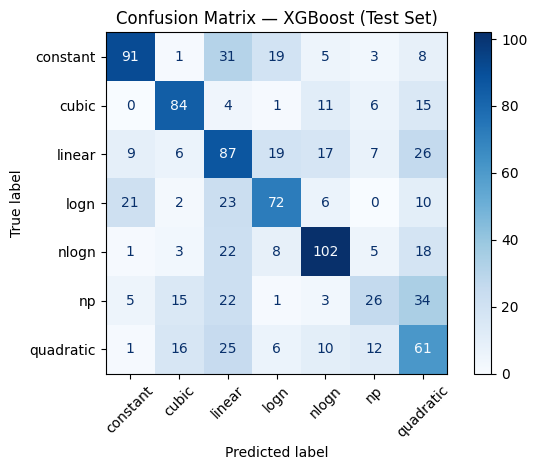

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=le.classes_)

disp_xgb = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=le.classes_
)

plt.figure(figsize=(8, 6))
disp_xgb.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — XGBoost (Test Set)")
plt.grid(False)
plt.tight_layout()
plt.show()

# MODEL 2 — Small MLP (Neural Baseline)

In [16]:
# FIX: Reuse the shared LabelEncoder (le) instead of creating a second one (le_mlp)
# This guarantees both models map classes identically
y_train_mlp = le.transform(y_train)
y_test_mlp  = le.transform(y_test)

print("Class mapping (shared):", dict(zip(le.classes_, range(len(le.classes_)))))

Class mapping (shared): {'constant': 0, 'cubic': 1, 'linear': 2, 'logn': 3, 'nlogn': 4, 'np': 5, 'quadratic': 6}


In [17]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report

In [18]:
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        max_iter=1000,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=42
    ))
])

In [19]:
mlp_param_grid = {
    "mlp__hidden_layer_sizes": [(32,), (64,), (64, 32)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__alpha": [1e-4, 1e-3, 1e-2],
    "mlp__learning_rate_init": [0.001, 0.005, 0.01]
}

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mlp_search = RandomizedSearchCV(
    estimator=mlp_pipeline,
    param_distributions=mlp_param_grid,
    n_iter=25,
    scoring="f1_macro",
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42,
    error_score="raise"
)

mlp_search.fit(X_train, y_train_mlp)

best_mlp = mlp_search.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits


In [21]:
y_pred_mlp = best_mlp.predict(X_test)
y_pred_mlp = le.inverse_transform(y_pred_mlp)   # FIX: use shared le, not le_mlp

print("Best parameters:")
print(mlp_search.best_params_)

print(classification_report(y_test, y_pred_mlp))

Best parameters:
{'mlp__learning_rate_init': 0.01, 'mlp__hidden_layer_sizes': (64, 32), 'mlp__alpha': 0.0001, 'mlp__activation': 'relu'}
              precision    recall  f1-score   support

    constant       0.71      0.55      0.62       158
       cubic       0.58      0.73      0.64       121
      linear       0.37      0.51      0.43       171
        logn       0.61      0.51      0.56       134
       nlogn       0.67      0.59      0.63       159
          np       0.47      0.19      0.27       106
   quadratic       0.34      0.44      0.39       131

    accuracy                           0.51       980
   macro avg       0.53      0.50      0.50       980
weighted avg       0.54      0.51      0.51       980



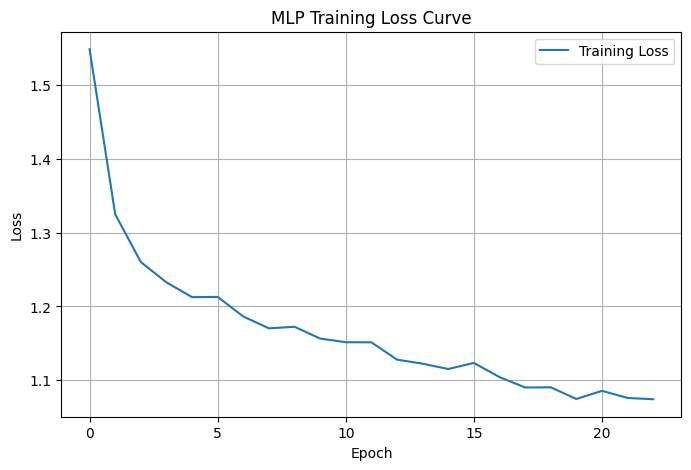

In [22]:
mlp_model = best_mlp.named_steps["mlp"]

# FIX: Guard loss_curve_ access — early stopping may produce a short but valid curve
if hasattr(mlp_model, 'loss_curve_') and mlp_model.loss_curve_:
    plt.figure(figsize=(8, 5))
    plt.plot(mlp_model.loss_curve_, label="Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("MLP Training Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No loss curve available (model may not have converged normally).")

<Figure size 800x600 with 0 Axes>

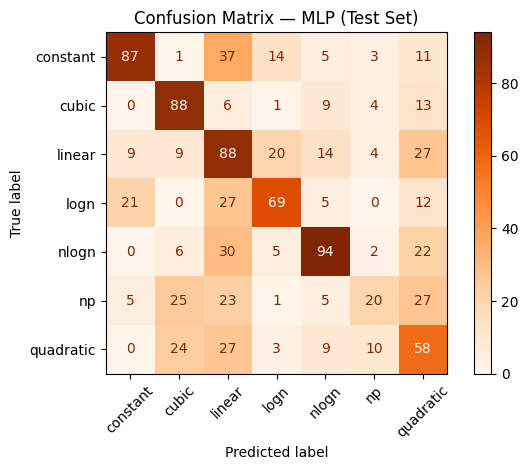

In [23]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp, labels=le.classes_)

disp_mlp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp,
    display_labels=le.classes_
)

plt.figure(figsize=(8, 6))
disp_mlp.plot(cmap="Oranges", xticks_rotation=45)
plt.title("Confusion Matrix — MLP (Test Set)")
plt.grid(False)
plt.tight_layout()
plt.show()

## Save Models

In [24]:
# Save the 2 trained models so you can download them from Kaggle
# Run this cell after training both models: best_xgb and best_mlp

import joblib
import json
import zipfile
from pathlib import Path
from IPython.display import FileLink, display

OUTPUT_DIR = Path("/kaggle/working/saved_models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save XGBoost model + the shared label encoder
joblib.dump(best_xgb, OUTPUT_DIR / "xgboost_model.joblib")
joblib.dump(le,       OUTPUT_DIR / "label_encoder.joblib")   # one encoder for both models

# Save MLP pipeline (already includes StandardScaler + MLP)
joblib.dump(best_mlp, OUTPUT_DIR / "mlp_pipeline.joblib")

# Save feature information needed later by the GUI/inference code
feature_info = {
    "feature_columns": list(X_train.columns),
    "drop_columns": DROP_COLUMNS,
    "target_column": "complexity",
    "categorical_columns": ["loop_bound_type"],
    "notes": "For prediction, create the same features, apply get_dummies, then reindex to feature_columns with fill_value=0."
}

with open(OUTPUT_DIR / "feature_info.json", "w", encoding="utf-8") as f:
    json.dump(feature_info, f, indent=2)

# Put everything in one downloadable zip file
zip_path = Path("/kaggle/working/complexity_models.zip")

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file_path in OUTPUT_DIR.iterdir():
        zipf.write(file_path, arcname=file_path.name)

print(f"Saved files in: {OUTPUT_DIR}")
print(f"Download zip: {zip_path}")

display(FileLink(str(zip_path)))

Saved files in: /kaggle/working/saved_models
Download zip: /kaggle/working/complexity_models.zip


/kaggle/working/complexity_models.zip